In [1]:
import pandas as pd
import numpy as np
import sklearn as sk

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import alpha

In [2]:
df_red = pd.read_csv('winequality-white.csv', delimiter=';')

df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
df_red.info()

print("Nulls - ", df_red.isnull().sum())

print("Stats - ", df_red.describe())

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
Nulls -  fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               

In [4]:
df_red['acidity_sum'] = df_red['fixed acidity'] + df_red['volatile acidity']
df_red['alcoh_acidity_ratio'] = df_red['alcohol'] / df_red['volatile acidity']

print(df_red.corr()['quality'].sort_values())

density                -0.307123
chlorides              -0.209934
volatile acidity       -0.194723
total sulfur dioxide   -0.174737
acidity_sum            -0.136320
fixed acidity          -0.113663
residual sugar         -0.097577
citric acid            -0.009209
free sulfur dioxide     0.008158
sulphates               0.053678
pH                      0.099427
alcoh_acidity_ratio     0.303144
alcohol                 0.435575
quality                 1.000000
Name: quality, dtype: float64


In [5]:
x = df_red.drop('quality', axis=1)
y = df_red['quality']

x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)

sc = sk.preprocessing.StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

model = sk.linear_model.RidgeCV(alphas=[0.5, 1.0, 10, 50], cv=5)
model.fit(x_train_scaled, y_train)

score = model.score(x_test_scaled, y_test)
print('Best alpha - ',model.alpha_)
print('Determination - ',score)

Best alpha -  10.0
Determination -  0.26545960948904046


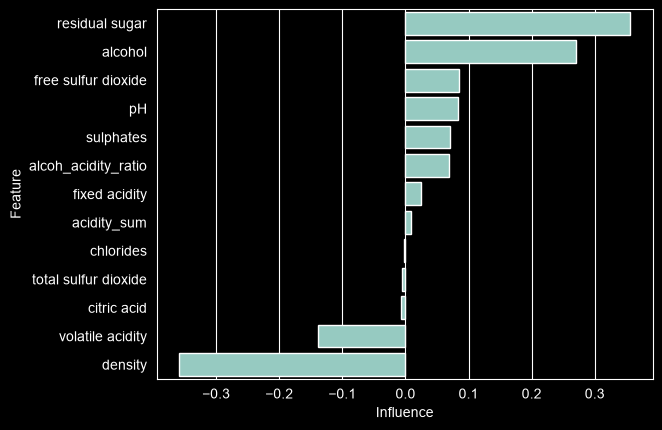

In [6]:
feature_influence = pd.DataFrame(
    {'Feature':x.columns, 'Influence':model.coef_}
).sort_values(by='Influence', ascending=False)

sns.barplot(data = feature_influence, x='Influence', y='Feature')
plt.show()

# This image shows that the most influence on the predict result has alcohol and density features

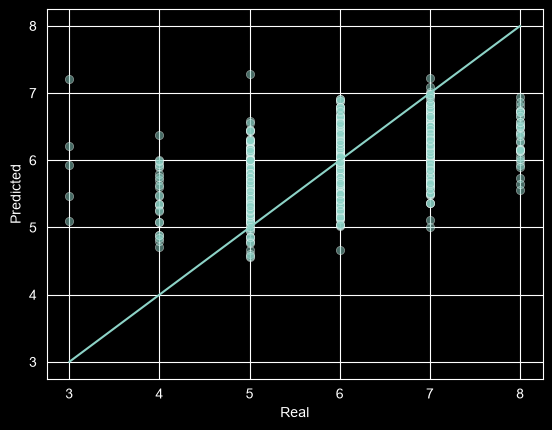

In [7]:
y_predicted = model.predict(x_test_scaled)

result = pd.DataFrame({'Real':y_test, 'Predicted': y_predicted})

sns.scatterplot(data=result, x='Real', y='Predicted', alpha=0.5)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()])
plt.show()

# This image shows that model predicted numbers 5, 6 the most frequently and 7 less frequently